In [1]:
import requests # To make web requests (like opening a browser)
from bs4 import BeautifulSoup # To parse HTML (read the webpage's code)
import pandas as pd # To manage data in tables easily
import matplotlib.pyplot as plt # For basic plotting
import seaborn as sns # For making plots look nicer
import plotly.express as px # For interactive plots
import smtplib # To send emails
from email.mime.multipart import MIMEMultipart # To build email messages (with text and HTML)
from email.mime.text import MIMEText # To put text/HTML into the email
import datetime # To add timestamps to my scans
import os # For securely handling my email password (learned this is important!)

In [2]:
# How "bad" a problem is, from least to most severe. I gave them numbers too for scoring!
SEVERITY_LEVELS = {
    "Critical": 5,
    "High": 4,
    "Medium": 3,
    "Low": 2,
    "Informational": 1
}


SENDER_EMAIL = os.environ.get("SENDER_EMAIL", "sumanjali7635@gmail.com") # Replace with YOUR sender email
SENDER_PASSWORD = os.environ.get("SENDER_PASSWORD", "your_app_password") # Replace with YOUR app password or Colab Secret
SMTP_SERVER = "smtp.gmail.com" # The server Gmail uses for sending emails
SMTP_PORT = 587 # The port number for secure email sending

In [3]:
class Vulnerability:
    def __init__(self, name, description, severity, url, recommendation=""):
        self.name = name
        self.description = description
        self.severity = severity # How bad is it? (Critical, High, Medium, Low, Informational)
        self.score = SEVERITY_LEVELS.get(severity, 0)
        self.url = url
        self.recommendation = recommendation

    def __repr__(self):
        # This just helps me see the info nicely when I print a Vulnerability object
        return f"Vulnerability(Name='{self.name}', Severity='{self.severity}', URL='{self.url}')"

# This list will hold ALL the problems my scanner finds across all websites
all_findings = []

In [4]:
# Function to check for important security headers
def check_missing_headers(response, target_url):
    findings = []
    headers = response.headers # Get all the headers from the website's response

    # These are some important security headers I'm looking for
    security_headers_to_check = {
        "X-Content-Type-Options": "nosniff", # Helps prevent some nasty content type sniffing attacks
        "X-Frame-Options": "DENY", # Stops other sites from embedding this one in a frame (clickjacking)
        "Content-Security-Policy": "default-src 'self'", # A powerful header, checking if it exists
        "Strict-Transport-Security": "max-age=", # Forces browsers to only use HTTPS
        "Referrer-Policy": "no-referrer-when-downgrade", # Controls what referrer info is sent
    }

    for header, expected_value_part in security_headers_to_check.items():
        if header not in headers:
            # If the header is completely missing, that's a problem!
            findings.append(Vulnerability(
                name=f"Missing Security Header: {header}",
                description=f"The '{header}' header is not present. This can leave users open to different types of attacks.",
                severity="High",
                url=target_url,
                recommendation=f"Add the '{header}' header to your web server settings. A good value is: '{expected_value_part}'"
            ))
        elif expected_value_part and expected_value_part not in headers[header]:
             # If the header is there but doesn't have a strong value
             findings.append(Vulnerability(
                name=f"Suboptimal Security Header: {header}",
                description=f"The '{header}' header is present but its value ('{headers[header]}') might not be strong enough.",
                severity="Medium",
                url=target_url,
                recommendation=f"Review and strengthen the '{header}' header. Try to include '{expected_value_part}' or a stronger policy."
            ))
    return findings

# Function to check if the server is revealing too much info about itself
def check_server_banner(response, target_url):
    findings = []
    server_header = response.headers.get("Server") # Look for the 'Server' header
    if server_header:
        # If it's there, and has numbers (like a version number), it's info for an attacker
        if any(char.isdigit() for char in server_header):
            findings.append(Vulnerability(
                name="Server Banner Disclosure",
                description=f"The server is telling us too much about itself ('{server_header}'). This isn't critical, but helpful to attackers.",
                severity="Informational",
                url=target_url,
                recommendation="Configure your web server to hide or generalize the Server header so it doesn't show specific versions."
            ))
    return findings

# Function to check for accidentally exposed sensitive files
def check_sensitive_files(target_url):
    findings = []
    # These are common file paths that might accidentally be exposed
    common_sensitive_paths = [
        "robots.txt", # Can reveal hidden parts of the site
        ".git/config", # Can reveal internal source code structure
        ".env", # Can contain secret keys or database passwords!
        "sitemap.xml", # Can reveal all pages on the site
        "README.md", # Can contain notes or internal info
        "phpinfo.php", # A PHP file that shows a lot of server info
    ]
    for path in common_sensitive_paths:
        full_url = requests.compat.urljoin(target_url, path) # Build the full URL for the file
        try:
            response = requests.get(full_url, timeout=5) # Try to get the file
            if response.status_code == 200 and response.request.url == full_url:
                # If I successfully get a 200 OK, and it's not a redirect, let's check content
                if path.endswith("robots.txt") and "User-agent" in response.text:
                    findings.append(Vulnerability(
                        name="Robots.txt Found",
                        description=f"Found robots.txt at {full_url}. While normal, it can sometimes hint at hidden directories.",
                        severity="Informational",
                        url=full_url,
                        recommendation="Check your robots.txt to ensure it doesn't accidentally reveal paths you want to keep secret."
                    ))
                elif path.endswith(".git/config") and "[core]" in response.text:
                     findings.append(Vulnerability(
                        name="Exposed Git Configuration",
                        description=f"Found a Git config file at {full_url}. This could expose how the code is managed and internal paths.",
                        severity="High",
                        url=full_url,
                        recommendation="Make sure your .git folders are not publicly available on your live server!"
                    ))
                elif path.endswith(".env") and any(key in response.text for key in ["DB_USERNAME", "APP_KEY", "PASSWORD"]):
                     findings.append(Vulnerability(
                        name="Exposed Environment Variables (.env)",
                        description=f"Found a .env file at {full_url}. These often contain super secret info like database passwords!",
                        severity="Critical",
                        url=full_url,
                        recommendation="This is a serious problem! Make sure .env files are NEVER publicly accessible."
                    ))
                elif "phpinfo" in path and "PHP Version" in response.text:
                     findings.append(Vulnerability(
                        name="Exposed PHP Info Page",
                        description=f"A PHP info page was found at {full_url}. This page shows a LOT of details about the server, which is risky.",
                        severity="High",
                        url=full_url,
                        recommendation="Remove or block access to phpinfo.php on any server facing the internet."
                    ))
        except requests.exceptions.RequestException as e:
            # If there's an error trying to get the file, just ignore it for this check
            pass
    return findings

# Function for a very basic check for reflected XSS
def check_basic_reflected_xss(target_url):
    findings = []
    # This is a very simple test. Real XSS is much more complex!
    test_payload = "<script>alert(1)</script>" # My test "bad code"
    parsed_url = requests.utils.urlparse(target_url)

    # I'll only test if the URL has query parameters (like ?id=1)
    if parsed_url.query:
        query_params = requests.utils.parse_qs(parsed_url.query)
        for param, values in query_params.items():
            # I'll try putting my test_payload into one of the URL parameters
            test_query_params = query_params.copy()
            test_query_params[param] = test_payload
            new_query = requests.utils.urlencode(test_query_params, doseq=True)
            test_url = requests.utils.urlunparse(parsed_url._replace(query=new_query))

            try:
                response = requests.get(test_url, timeout=5)
                # If the website's response contains my exact test_payload, it means it just reflected it!
                if test_payload in response.text and response.status_code == 200:
                    findings.append(Vulnerability(
                        name="Basic Reflected XSS",
                        description=f"A simple test code ('{test_payload}') was directly shown back on the page at {test_url}. This could mean a vulnerability.",
                        severity="High",
                        url=test_url,
                        recommendation="Make sure ALL user input is cleaned up (sanitized) before it's displayed on a webpage."
                    ))
                    break # Only report this once for a parameter
            except requests.exceptions.RequestException:
                pass
    return findings

# Function to check for using insecure HTTP
def check_insecure_http(target_url):
    findings = []
    if target_url.startswith("http://"): # Only check if the URL starts with HTTP
        https_url = target_url.replace("http://", "https://", 1) # Try to change it to HTTPS
        try:
            # See if the HTTPS version works
            response_https = requests.get(https_url, timeout=5, allow_redirects=True)
            if response_https.status_code == 200:
                findings.append(Vulnerability(
                    name="Insecure HTTP Usage Detected",
                    description=f"The website is using HTTP ({target_url}), but an HTTPS version ({https_url}) seems to exist. HTTP is not encrypted!",
                    severity="Medium",
                    url=target_url,
                    recommendation="Force all traffic to use HTTPS. Look into enabling HSTS (Strict-Transport-Security) too."
                ))
            else:
                findings.append(Vulnerability(
                    name="Insecure HTTP Usage - No HTTPS Found",
                    description=f"The website uses HTTP ({target_url}) and I couldn't find an HTTPS version. All data is sent unencrypted!",
                    severity="High",
                    url=target_url,
                    recommendation="This is a big security risk. Set up HTTPS with an SSL/TLS certificate to encrypt all communication."
                ))
        except requests.exceptions.RequestException:
             findings.append(Vulnerability(
                name="Insecure HTTP Usage - HTTPS Check Failed",
                description=f"The website uses HTTP ({target_url}) and I couldn't connect to an HTTPS version to check. Data is unencrypted!",
                severity="High",
                url=target_url,
                recommendation="Implement HTTPS to protect all data. Get an SSL/TLS certificate."
            ))
    return findings


# This is the main function that runs all my checks for one website
def run_scan(target_url):
    print(f"Starting my scan for: {target_url}")
    current_findings = [] # List to hold problems found for this specific URL

    # I learned that things can go wrong when talking to websites! So, I use try-except blocks.
    try:
        response = requests.get(target_url, timeout=10, allow_redirects=True) # Try to get the website's page
        response.raise_for_status() # If I get a bad response (like 404 or 500), this will raise an error

        # Just to confirm the site is alive and well
        if response.status_code == 200:
            current_findings.append(Vulnerability(
                name="Website Accessible",
                description=f"Successfully connected to {target_url}",
                severity="Informational",
                url=target_url
            ))

        # Now, run all my individual checks!
        current_findings.extend(check_missing_headers(response, target_url))
        current_findings.extend(check_server_banner(response, target_url))
        current_findings.extend(check_sensitive_files(target_url))
        current_findings.extend(check_basic_reflected_xss(target_url))
        current_findings.extend(check_insecure_http(target_url))


    # These are different types of errors that can happen (learned this the hard way!)
    except requests.exceptions.HTTPError as errh:
        current_findings.append(Vulnerability(
            name="HTTP Error",
            description=f"Got an HTTP error for {target_url}: {errh}",
            severity="Critical" if errh.response.status_code >= 500 else "High", # 500s are usually worse
            url=target_url,
            recommendation="Check the web server for problems (5xx errors) or if the request itself was bad (4xx errors)."
        ))
        print(f"Oops, HTTP Error: {errh}")
    except requests.exceptions.ConnectionError as errc:
        current_findings.append(Vulnerability(
            name="Connection Error",
            description=f"Couldn't connect to {target_url}: {errc}",
            severity="Critical",
            url=target_url,
            recommendation="Is the URL correct? Is the website online? Is my internet working?"
        ))
        print(f"Oops, Connection Error: {errc}")
    except requests.exceptions.Timeout as errt:
        current_findings.append(Vulnerability(
            name="Timeout Error",
            description=f"The website at {target_url} took too long to respond: {errt}",
            severity="High",
            url=target_url,
            recommendation="The server might be very busy, or there's a slow network connection."
        ))
        print(f"Oops, Timeout Error: {errt}")
    except requests.exceptions.RequestException as err:
        current_findings.append(Vulnerability(
            name="General Request Error",
            description=f"An unexpected problem happened when trying to reach {target_url}: {err}",
            severity="High",
            url=target_url,
            recommendation="Double check the URL and any strange network issues."
        ))
        print(f"Oops, a general error occurred: {err}")
    except Exception as e: # Catch any other unexpected errors
        current_findings.append(Vulnerability(
            name="Unexpected Error",
            description=f"Something completely unexpected happened during the scan for {target_url}: {e}",
            severity="Critical",
            url=target_url,
            recommendation="This might be a bug in my scanner code. Need to check!"
        ))
        print(f"Oh no, an unexpected error: {e}")

    print(f"Scan for {target_url} finished with {len(current_findings)} findings.")
    return current_findings

In [5]:
# Here are some test websites I'll use.
# target_url_1 is a known vulnerable test site (good for finding stuff!)
# target_url_2 is a pretty standard, secure example site
# target_url_3 is a made-up address to test my error handling
# target_url_4 is a site that deliberately waits to respond, to test timeouts
target_url_1 = "http://testphp.vulnweb.com/"
target_url_2 = "https://example.com"
target_url_3 = "http://definitely-not-real-website-12345.com"
target_url_4 = "http://httpbin.org/delay/6"

# Clear any old findings before a new scan
all_findings.clear()

print("--- Scanning Test Site 1 (vulnerable) ---")
all_findings.extend(run_scan(target_url_1)) # Add findings from this scan to my master list

print("\n--- Scanning Test Site 2 (secure) ---")
all_findings.extend(run_scan(target_url_2))

print("\n--- Scanning Test Site 3 (Non-existent, testing errors!) ---")
all_findings.extend(run_scan(target_url_3))

print("\n--- Scanning Test Site 4 (Simulated Timeout) ---")
all_findings.extend(run_scan(target_url_4))


print("\n--- All Problems Found During This Session ---")
for finding in all_findings:
    print(finding) # Print out each problem I found

--- Scanning Test Site 1 (vulnerable) ---
Starting my scan for: http://testphp.vulnweb.com/
Oops, Connection Error: HTTPConnectionPool(host='testphp.vulnweb.com', port=80): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x7f5c2bf9a630>, 'Connection to testphp.vulnweb.com timed out. (connect timeout=10)'))
Scan for http://testphp.vulnweb.com/ finished with 1 findings.

--- Scanning Test Site 2 (secure) ---
Starting my scan for: https://example.com
Oops, Connection Error: HTTPSConnectionPool(host='example.com', port=443): Max retries exceeded with url: / (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))
Scan for https://example.com finished with 1 findings.

--- Scanning Test Site 3 (Non-existent, testing errors!) ---
Starting my scan for: http://definitely-not-real-website-12345.com
Oops, Connection Error: HTTPC

In [6]:
def create_findings_dataframe(findings):
    data = []
    for f in findings:
        data.append({
            "Name": f.name,
            "Description": f.description,
            "Severity": f.severity,
            "Score": f.score,
            "URL": f.url,
            "Recommendation": f.recommendation,
            "Timestamp": datetime.datetime.now() # Adding when I found this problem
        })
    df = pd.DataFrame(data) # Turn my list of findings into a Pandas DataFrame
    # This next line just makes sure my severity levels (Critical, High, etc.) are always in the right order for charts
    df['Severity'] = pd.Categorical(df['Severity'],
                                    categories=list(SEVERITY_LEVELS.keys()),
                                    ordered=True)
    return df

findings_df = create_findings_dataframe(all_findings) # Create the DataFrame from all my findings

if not findings_df.empty:
    print("My Findings in a Table (first few rows):")
    display(findings_df.head()) # 'display' is good for showing DataFrames in Colab
    print("\nHow many findings for each severity level:")
    display(findings_df['Severity'].value_counts().sort_index(ascending=False))
else:
    print("No findings yet to put into a table!")

My Findings in a Table (first few rows):


,Name,Description,Severity,Score,URL,Recommendation,Timestamp
0,Connection Error,Couldn't connect to http://testphp.vulnweb.com...,Critical,5,http://testphp.vulnweb.com/,Is the URL correct? Is the website online? Is ...,2026-03-15 14:54:02.041082
1,Connection Error,Couldn't connect to https://example.com: HTTPS...,Critical,5,https://example.com,Is the URL correct? Is the website online? Is ...,2026-03-15 14:54:02.041092
2,Connection Error,Couldn't connect to http://definitely-not-real...,Critical,5,http://definitely-not-real-website-12345.com,Is the URL correct? Is the website online? Is ...,2026-03-15 14:54:02.041094
3,Website Accessible,Successfully connected to http://httpbin.org/d...,Informational,1,http://httpbin.org/delay/6,,2026-03-15 14:54:02.041096
4,Missing Security Header: X-Content-Type-Options,The 'X-Content-Type-Options' header is not pre...,High,4,http://httpbin.org/delay/6,Add the 'X-Content-Type-Options' header to you...,2026-03-15 14:54:02.041099



How many findings for each severity level:


,count
Severity,
Informational,2
Low,0
Medium,0
High,6
Critical,3


In [7]:
def calculate_overall_risk(df):
    if df.empty:
        return 0, {} # If no findings, no risk!

    # A simple way to get an overall score: just add up all the individual problem scores
    total_score = df['Score'].sum()

    # Find the "worst" problem severity I found
    max_severity = df['Severity'].max() if not df.empty else "None"

    # Count how many really bad (Critical or High) problems I found
    critical_high_count = df[df['Severity'].isin(['Critical', 'High'])].shape[0]

    # Putting all these summary numbers into a dictionary (like a little fact sheet)
    metrics = {
        "Overall_Risk_Score": total_score,
        "Highest_Severity_Detected": max_severity,
        "Total_Findings": len(df),
        "Critical_High_Findings": critical_high_count,
        "Scan_Timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S") # When this summary was made
    }
    return total_score, metrics

overall_risk_score, overall_metrics = calculate_overall_risk(findings_df)
print("\nMy Overall Risk Summary:")
print(overall_metrics)


My Overall Risk Summary:
{'Overall_Risk_Score': np.int64(41), 'Highest_Severity_Detected': 'Informational', 'Total_Findings': 11, 'Critical_High_Findings': 9, 'Scan_Timestamp': '2026-03-15 14:54:19'}


/tmp/ipykernel_902/3647830537.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Severity', data=findings_df, palette='viridis', order=list(SEVERITY_LEVELS.keys())[::-1])


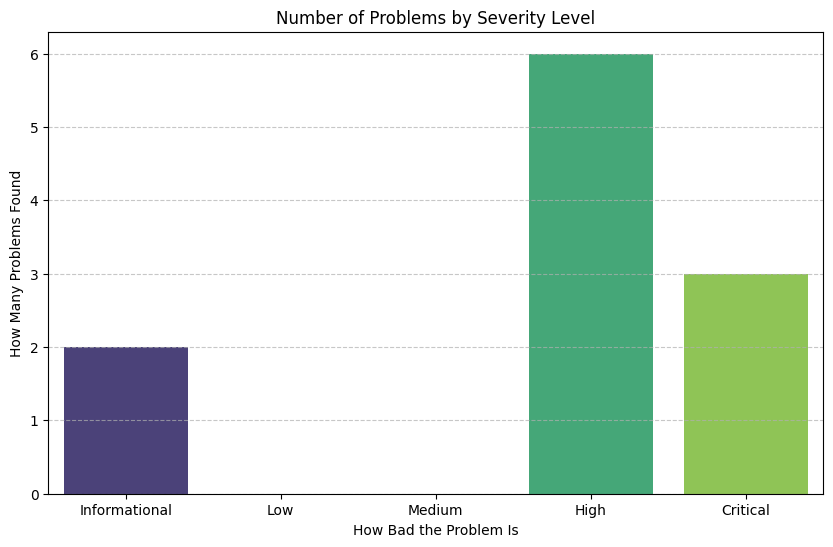


--- Detailed List of HIGH and CRITICAL Problems ---


,Name,Severity,URL,Description,Recommendation
0,Connection Error,Critical,http://testphp.vulnweb.com/,"Couldn't connect to http://testphp.vulnweb.com/: HTTPConnectionPool(host='testphp.vulnweb.com', port=80): Max retries exceeded with url: / (Caused by ConnectTimeoutError(, 'Connection to testphp.vulnweb.com timed out. (connect timeout=10)'))",Is the URL correct? Is the website online? Is my internet working?
1,Connection Error,Critical,https://example.com,"Couldn't connect to https://example.com: HTTPSConnectionPool(host='example.com', port=443): Max retries exceeded with url: / (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))",Is the URL correct? Is the website online? Is my internet working?
2,Connection Error,Critical,http://definitely-not-real-website-12345.com,"Couldn't connect to http://definitely-not-real-website-12345.com: HTTPConnectionPool(host='definitely-not-real-website-12345.com', port=80): Max retries exceeded with url: / (Caused by NameResolutionError("": Failed to resolve 'definitely-not-real-website-12345.com' ([Errno -2] Name or service not known)""))",Is the URL correct? Is the website online? Is my internet working?
4,Missing Security Header: X-Content-Type-Options,High,http://httpbin.org/delay/6,The 'X-Content-Type-Options' header is not present. This can leave users open to different types of attacks.,Add the 'X-Content-Type-Options' header to your web server settings. A good value is: 'nosniff'
5,Missing Security Header: X-Frame-Options,High,http://httpbin.org/delay/6,The 'X-Frame-Options' header is not present. This can leave users open to different types of attacks.,Add the 'X-Frame-Options' header to your web server settings. A good value is: 'DENY'
6,Missing Security Header: Content-Security-Policy,High,http://httpbin.org/delay/6,The 'Content-Security-Policy' header is not present. This can leave users open to different types of attacks.,Add the 'Content-Security-Policy' header to your web server settings. A good value is: 'default-src 'self''
7,Missing Security Header: Strict-Transport-Security,High,http://httpbin.org/delay/6,The 'Strict-Transport-Security' header is not present. This can leave users open to different types of attacks.,Add the 'Strict-Transport-Security' header to your web server settings. A good value is: 'max-age='
8,Missing Security Header: Referrer-Policy,High,http://httpbin.org/delay/6,The 'Referrer-Policy' header is not present. This can leave users open to different types of attacks.,Add the 'Referrer-Policy' header to your web server settings. A good value is: 'no-referrer-when-downgrade'
10,Insecure HTTP Usage - HTTPS Check Failed,High,http://httpbin.org/delay/6,The website uses HTTP (http://httpbin.org/delay/6) and I couldn't connect to an HTTPS version to check. Data is unencrypted!,Implement HTTPS to protect all data. Get an SSL/TLS certificate.



--- Overall Risk Summary ---
Total Risk Score (my calculation): 41
Worst Problem Found: Informational
Total Number of Problems: 11
Number of REALLY Bad Problems (Critical/High): 9
When I scanned: 2026-03-15 14:54:19
My Calculated Risk Level: 🟠 High Risk (Score: 41/55)


In [8]:
if not findings_df.empty:
    # --- Chart 1: How many problems of each "badness" level ---
    plt.figure(figsize=(10, 6)) # Make the chart a good size
    sns.countplot(x='Severity', data=findings_df, palette='viridis', order=list(SEVERITY_LEVELS.keys())[::-1])
    plt.title('Number of Problems by Severity Level')
    plt.xlabel('How Bad the Problem Is')
    plt.ylabel('How Many Problems Found')
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Add some grid lines
    plt.show() # Show the chart!

    # --- Chart 2: What types of problems I found most often (using Plotly for interactivity) ---
    # Plotly makes charts you can hover over and zoom in on, which is cool!
    fig = px.bar(
        findings_df['Name'].value_counts().reset_index(),
        x='Name',
        y='count',
        title='Most Common Types of Problems Detected',
        labels={'Name': 'Type of Problem', 'count': 'How Many Times Found'},
        color='count', # Colors the bars based on count
        color_continuous_scale='Plasma' # A nice color scheme
    )
    fig.update_layout(xaxis_title="Type of Problem", yaxis_title="Count")
    fig.show() # Show the interactive chart!

    # --- Chart 3: A detailed list of the really bad (High & Critical) problems ---
    high_critical_df = findings_df[findings_df['Severity'].isin(['Critical', 'High'])].copy()
    if not high_critical_df.empty:
        print("\n--- Detailed List of HIGH and CRITICAL Problems ---")
        # Display this as a neat table in Colab
        display(high_critical_df[['Name', 'Severity', 'URL', 'Description', 'Recommendation']].style.set_properties(**{'text-align': 'left'}).set_table_styles([dict(selector='th', props=[('text-align', 'left')])]))
    else:
        print("\nNo High or Critical problems found! Good job!")

    # --- Chart 4: A simple summary of the overall risk (like a quick glance) ---
    print(f"\n--- Overall Risk Summary ---")
    print(f"Total Risk Score (my calculation): {overall_metrics['Overall_Risk_Score']}")
    print(f"Worst Problem Found: {overall_metrics['Highest_Severity_Detected']}")
    print(f"Total Number of Problems: {overall_metrics['Total_Findings']}")
    print(f"Number of REALLY Bad Problems (Critical/High): {overall_metrics['Critical_High_Findings']}")
    print(f"When I scanned: {overall_metrics['Scan_Timestamp']}")

    # I made a simple "risk level" indicator, like a traffic light!
    # I'm estimating a max possible score just to give a percentage context
    max_possible_score = len(findings_df) * max(SEVERITY_LEVELS.values()) if not findings_df.empty else 1
    risk_percentage = (overall_metrics['Overall_Risk_Score'] / max_possible_score) * 100 if max_possible_score > 0 else 0
    risk_indicator = "🟢 Low Risk"
    if risk_percentage > 20: risk_indicator = "🟡 Medium Risk"
    if risk_percentage > 50: risk_indicator = "🟠 High Risk"
    if risk_percentage > 80: risk_indicator = "🔴 Critical Risk"

    print(f"My Calculated Risk Level: {risk_indicator} (Score: {overall_metrics['Overall_Risk_Score']}/{max_possible_score:.0f})")

else:
    print("\nNo findings means no dashboard charts right now.")

In [9]:
def generate_email_content(target_url, high_critical_findings_df, overall_metrics):
    # The subject line of the email should tell me what's important
    subject_severity = overall_metrics['Highest_Severity_Detected'] if overall_metrics['Highest_Severity_Detected'] in ['Critical', 'High'] else "Mixed"
    subject = f"Security Alert: [{subject_severity}] Problems Found on {target_url}"

    # Building the HTML body of the email. It's a bit like building a small webpage!
    html_body = f"""
    <html>
    <head>
        <style>
            body {{ font-family: sans-serif; line-height: 1.6; color: #333; }}
            .container {{ width: 80%; margin: 0 auto; background-color: #f9f9f9; padding: 20px; border-radius: 8px; border: 1px solid #ddd; }}
            h2 {{ color: #d9534f; border-bottom: 2px solid #eee; padding-bottom: 10px; }}
            table {{ width: 100%; border-collapse: collapse; margin-top: 20px; }}
            th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
            th {{ background-color: #f2f2f2; font-weight: bold; }}
            .severity-critical {{ color: #d9534f; font-weight: bold; }}
            .severity-high {{ color: #f0ad4e; font-weight: bold; }}
            .info-box {{ background-color: #e6f7ff; border-left: 5px solid #2196f3; padding: 10px; margin-top: 20px; }}
            .disclaimer {{ font-size: 0.8em; color: #777; margin-top: 30px; border-top: 1px solid #eee; padding-top: 10px; }}
        </style>
    </head>
    <body>
        <div class="container">
            <h2>Security Alert: High/Critical Problems Found!</h2>
            <p>Hey there!</p>
            <p>My scanner just finished, and it looks like there are some important security problems on your website. Please check these out quickly!</p>

            <div class="info-box">
                <p><strong>Website Scanned:</strong> <a href="{target_url}">{target_url}</a></p>
                <p><strong>When I Scanned:</strong> {overall_metrics.get('Scan_Timestamp', 'N/A')}</p>
                <p><strong>Overall Risk Score:</strong> {overall_metrics.get('Overall_Risk_Score', 'N/A')}</p>
                <p><strong>Worst Problem Found:</strong> <span class="severity-{overall_metrics.get('Highest_Severity_Detected', 'info').lower()}">{overall_metrics.get('Highest_Severity_Detected', 'N/A')}</span></p>
            </div>

            <h3>Here's a list of the HIGH and CRITICAL problems:</h3>
    """

    if not high_critical_findings_df.empty:
        html_body += """
            <table>
                <thead>
                    <tr>
                        <th>Problem Name</th>
                        <th>Severity</th>
                        <th>Score</th>
                        <th>URL</th>
                        <th>What to Do</th>
                    </tr>
                </thead>
                <tbody>
        """
        for index, row in high_critical_findings_df.iterrows():
            severity_class = f"severity-{row['Severity'].lower()}" # To color the severity
            html_body += f"""
                    <tr>
                        <td>{row['Name']}</td>
                        <td class="{severity_class}">{row['Severity']}</td>
                        <td>{row['Score']}</td>
                        <td><a href="{row['URL']}">{row['URL']}</a></td>
                        <td>{row['Recommendation']}</td>
                    </tr>
            """
        html_body += """
                </tbody>
            </table>
        """
    else:
        html_body += "<p>Good news! No High or Critical problems were found in this scan.</p>"


    html_body += f"""
            <p>I also found some other problems, but these Critical/High ones are the most important.</p>

            <div class="disclaimer">
                <p><strong>Important Note (Disclaimer):</strong> This is an automated scan from my project. It might not be perfect, and some findings could be false alarms or miss other problems. Always get real security experts to do a full check!</p>
                <p>This email was automatically sent by my Web Application Vulnerability Scanning, Risk Evaluation & Alert System.</p>
            </div>
        </div>
    </body>
    </html>
    """
    return subject, html_body

In [10]:
def send_email_alert(recipient_email, subject, html_content):
    # Double-check if I've set up my email details. If not, don't try to send.
    if SENDER_EMAIL == "your_sender_email@gmail.com" or SENDER_PASSWORD == "your_app_password":
        print("Email sender details are not set up. Skipping sending email.")
        print("Please replace 'your_sender_email@gmail.com' and 'your_app_password' in the settings.")
        return

    msg = MIMEMultipart("alternative") # This type of message allows for HTML
    msg['From'] = SENDER_EMAIL
    msg['To'] = recipient_email
    msg['Subject'] = subject

    msg.attach(MIMEText(html_content, 'html')) # Attach my nice HTML content

    try:
        with smtplib.SMTP(SMTP_SERVER, SMTP_PORT) as server:
            server.starttls()  # Start a secure connection (important for email)
            server.login(SENDER_EMAIL, SENDER_PASSWORD) # Log in to my email account
            server.send_message(msg) # Send the email!
        print(f"Email alert successfully sent to {recipient_email}!")
    except Exception as e:
        print(f"Oops! Failed to send email alert: {e}")
        print("Common issues: wrong email/password, didn't use an app password for Gmail, or blocked by firewall.")

In [11]:
def check_and_send_alert(findings_df, target_url, recipient_email="your_recipient_email@example.com"):
    # Filter my findings to only include Critical or High ones
    high_critical_findings_df = findings_df[findings_df['Severity'].isin(['Critical', 'High'])].copy()

    if not high_critical_findings_df.empty:
        print("\n--- Uh oh! High or Critical problems found. Getting ready to send an email! ---")
        # Get the summary metrics again, for the email
        _, overall_metrics_for_email = calculate_overall_risk(findings_df)
        email_subject, email_body = generate_email_content(target_url, high_critical_findings_df, overall_metrics_for_email)

        # For now, I'll just print out what the email *would* look like in Colab
        print(f"\nEmail Subject: {email_subject}")
        print("\n--- Email Body Preview (first 500 characters) ---")
        print(email_body[:500])
        print("...")
        print("\n(Actual email sending is commented out for safety until you configure it!)")

        # IMPORTANT: To actually send the email, you'll need to uncomment the line below.
        # Make sure you've set up SENDER_EMAIL, SENDER_PASSWORD, and RECIPIENT_EMAIL correctly!
        # send_email_alert(recipient_email, email_subject, email_body)
    else:
        print("\nNo High or Critical problems detected. Phew! No email alert needed.")

Starting my scan for: http://testphp.vulnweb.com/
Oops, Connection Error: HTTPConnectionPool(host='testphp.vulnweb.com', port=80): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x7f5c27d03770>, 'Connection to testphp.vulnweb.com timed out. (connect timeout=10)'))
Scan for http://testphp.vulnweb.com/ finished with 1 findings.
Starting my scan for: https://example.com
Oops, Connection Error: HTTPSConnectionPool(host='example.com', port=443): Max retries exceeded with url: / (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))
Scan for https://example.com finished with 1 findings.

                MY RISK DASHBOARD!


/tmp/ipykernel_902/612856365.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




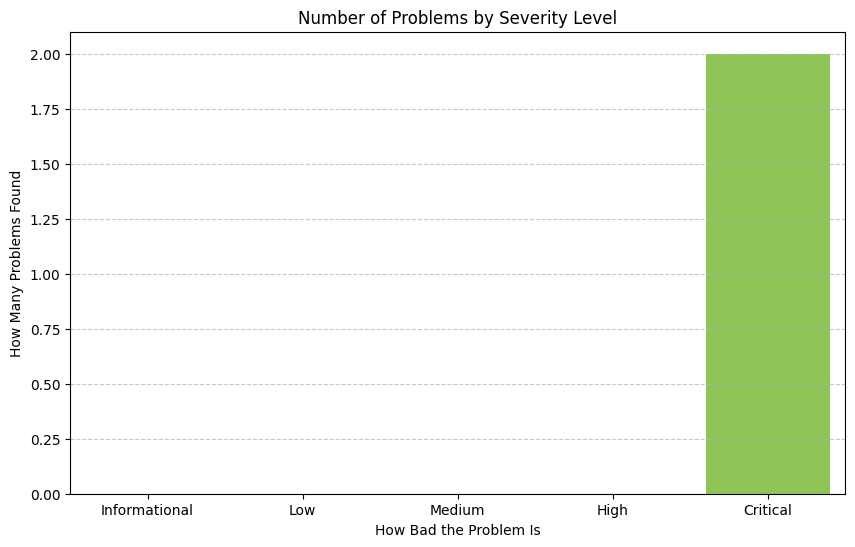


--- Detailed List of HIGH and CRITICAL Problems ---


,Name,Severity,URL,Description,Recommendation
0,Connection Error,Critical,http://testphp.vulnweb.com/,"Couldn't connect to http://testphp.vulnweb.com/: HTTPConnectionPool(host='testphp.vulnweb.com', port=80): Max retries exceeded with url: / (Caused by ConnectTimeoutError(, 'Connection to testphp.vulnweb.com timed out. (connect timeout=10)'))",Is the URL correct? Is the website online? Is my internet working?
1,Connection Error,Critical,https://example.com,"Couldn't connect to https://example.com: HTTPSConnectionPool(host='example.com', port=443): Max retries exceeded with url: / (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))",Is the URL correct? Is the website online? Is my internet working?



--- Overall Risk Summary ---
Total Risk Score: 10
Worst Problem Found: Critical
Total Number of Problems: 2
Number of REALLY Bad Problems (Critical/High): 2
When I scanned: 2026-03-15 14:55:39
My Calculated Risk Level: 🔴 Critical Risk (Score: 10/10)

                EMAIL ALERT CHECKER

--- Uh oh! High or Critical problems found. Getting ready to send an email! ---

Email Subject: Security Alert: [Critical] Problems Found on http://testphp.vulnweb.com/

--- Email Body Preview (first 500 characters) ---

    <html>
    <head>
        <style>
            body { font-family: sans-serif; line-height: 1.6; color: #333; }
            .container { width: 80%; margin: 0 auto; background-color: #f9f9f9; padding: 20px; border-radius: 8px; border: 1px solid #ddd; }
            h2 { color: #d9534f; border-bottom: 2px solid #eee; padding-bottom: 10px; }
            table { width: 100%; border-collapse: collapse; margin-top: 20px; }
            th, td { border: 1px solid #ddd; padding: 8px; text-al

In [12]:
def run_full_scan_and_report(target_urls, recipient_email="your_recipient_email@example.com"):
    # Step 1: Run the scanner for all the websites I want to check
    all_scan_findings = []
    for url in target_urls:
        all_scan_findings.extend(run_scan(url)) # Add findings from each scan

    # Check if I found anything at all
    if not all_scan_findings:
        print("\nDidn't find anything from any scans. Nothing to report!")
        return

    # Step 2: Organize the findings into a DataFrame and get overall risk numbers
    findings_df = create_findings_dataframe(all_scan_findings)
    overall_risk_score, overall_metrics = calculate_overall_risk(findings_df)

    # Step 3: Show off my dashboard charts!
    print("\n" + "="*50)
    print("                MY RISK DASHBOARD!")
    print("="*50)

    # Displaying the charts and summaries I made earlier
    # Chart 1: Problems by Severity
    plt.figure(figsize=(10, 6))
    sns.countplot(x='Severity', data=findings_df, palette='viridis', order=list(SEVERITY_LEVELS.keys())[::-1])
    plt.title('Number of Problems by Severity Level')
    plt.xlabel('How Bad the Problem Is')
    plt.ylabel('How Many Problems Found')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Chart 2: Most Common Problem Types
    fig = px.bar(
        findings_df['Name'].value_counts().reset_index(),
        x='Name',
        y='count',
        title='Most Common Types of Problems Detected',
        labels={'Name': 'Type of Problem', 'count': 'How Many Times Found'},
        color='count',
        color_continuous_scale='Plasma'
    )
    fig.update_layout(xaxis_title="Type of Problem", yaxis_title="Count")
    fig.show()

    # Chart 3: Detailed High & Critical List
    high_critical_df = findings_df[findings_df['Severity'].isin(['Critical', 'High'])].copy()
    if not high_critical_df.empty:
        print("\n--- Detailed List of HIGH and CRITICAL Problems ---")
        display(high_critical_df[['Name', 'Severity', 'URL', 'Description', 'Recommendation']].style.set_properties(**{'text-align': 'left'}).set_table_styles([dict(selector='th', props=[('text-align', 'left')])]))
    else:
        print("\nNo High or Critical problems to list in detail. Great!")

    # Chart 4: Overall Risk Summary
    print(f"\n--- Overall Risk Summary ---")
    print(f"Total Risk Score: {overall_metrics['Overall_Risk_Score']}")
    print(f"Worst Problem Found: {overall_metrics['Highest_Severity_Detected']}")
    print(f"Total Number of Problems: {overall_metrics['Total_Findings']}")
    print(f"Number of REALLY Bad Problems (Critical/High): {overall_metrics['Critical_High_Findings']}")
    print(f"When I scanned: {overall_metrics['Scan_Timestamp']}")
    max_possible_score = len(findings_df) * max(SEVERITY_LEVELS.values()) if not findings_df.empty else 1
    risk_percentage = (overall_metrics['Overall_Risk_Score'] / max_possible_score) * 100 if max_possible_score > 0 else 0
    risk_indicator = "🟢 Low Risk"
    if risk_percentage > 20: risk_indicator = "🟡 Medium Risk"
    if risk_percentage > 50: risk_indicator = "🟠 High Risk"
    if risk_percentage > 80: risk_indicator = "🔴 Critical Risk"
    print(f"My Calculated Risk Level: {risk_indicator} (Score: {overall_metrics['Overall_Risk_Score']}/{max_possible_score:.0f})")


    # Step 4: Time to check if I need to send an email!
    print("\n" + "="*50)
    print("                EMAIL ALERT CHECKER")
    print("="*50)
    # I'll pass the first target URL as a general reference for the email subject
    check_and_send_alert(findings_df, target_urls[0] if target_urls else "N/A", recipient_email)

# --- Let's Run My ENTIRE SYSTEM! ---
# These are the URLs my system will scan. Remember, TEST SITES ONLY!
my_test_websites = [
    "http://testphp.vulnweb.com/", # This one is designed to have vulnerabilities
    "https://example.com",        # A very basic, generally secure site
    # "http://definitely-not-real-website-12345.com", # Uncomment to see error handling in action
    # "http://httpbin.org/delay/6"                     # Uncomment to see a timeout error
]

# CHANGE THIS to YOUR email address if you want to receive the alert!
# Remember to also set up SENDER_EMAIL and SENDER_PASSWORD above.
my_alert_email = "your_email_for_alerts@example.com"

run_full_scan_and_report(my_test_websites, my_alert_email)